# 01 — Signal extraction

Load the marketing-team's weekly CSV (`paid_dau_weekly_forecast.20260519.csv`), eyeball the magnitudes against the STMO 118452 dashboard, document the three live caveats, and write a cleaned weekly parquet for `02_forecast_projection.ipynb` to consume.

**Sanity check is visual** — open https://sql.telemetry.mozilla.org/queries/118452/source side-by-side with the `plot-raw-weekly` plot below.


In [1]:
# [setup]
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

CSV_PATH = Path('data/paid_dau_weekly_forecast.20260519.csv')
CLEAN_PARQUET = Path('data/weekly_paid_dau_clean.parquet')
CAMPAIGN_LAUNCH = pd.Timestamp('2026-04-06')


In [2]:
# [load-csv]
def _strip_thousands(value):
    if isinstance(value, str):
        return int(value.replace(',', ''))
    return value


weekly = pd.read_csv(CSV_PATH, parse_dates=['week'])
for col in ['baseline_dau', 'post_2026_dau', 'total_paid_dau']:
    weekly[col] = weekly[col].map(_strip_thousands).astype('int64')
weekly = weekly.sort_values('week').reset_index(drop=True)
weekly = weekly.rename(columns={'week': 'week_starting'})

assert (weekly['week_starting'].dt.dayofweek == 0).all(), \
    'expected all CSV week dates to be Mondays'

print(f'Loaded {len(weekly)} weekly rows from {CSV_PATH}')
print(f'Date range: {weekly["week_starting"].min().date()} → {weekly["week_starting"].max().date()}')
print()
print(weekly.head(3).to_string(index=False))
print('  ...')
print(weekly.tail(3).to_string(index=False))


Loaded 52 weekly rows from data/paid_dau_weekly_forecast.20260519.csv
Date range: 2026-01-05 → 2026-12-28

week_starting  baseline_dau  post_2026_dau  total_paid_dau
   2026-01-05        523070          92908          615978
   2026-01-12        523070         139680          662750
   2026-01-19        523070         172863          695933
  ...
week_starting  baseline_dau  post_2026_dau  total_paid_dau
   2026-12-14        523070         938915         1461985
   2026-12-21        523070         944850         1467920
   2026-12-28        523070         950773         1473843


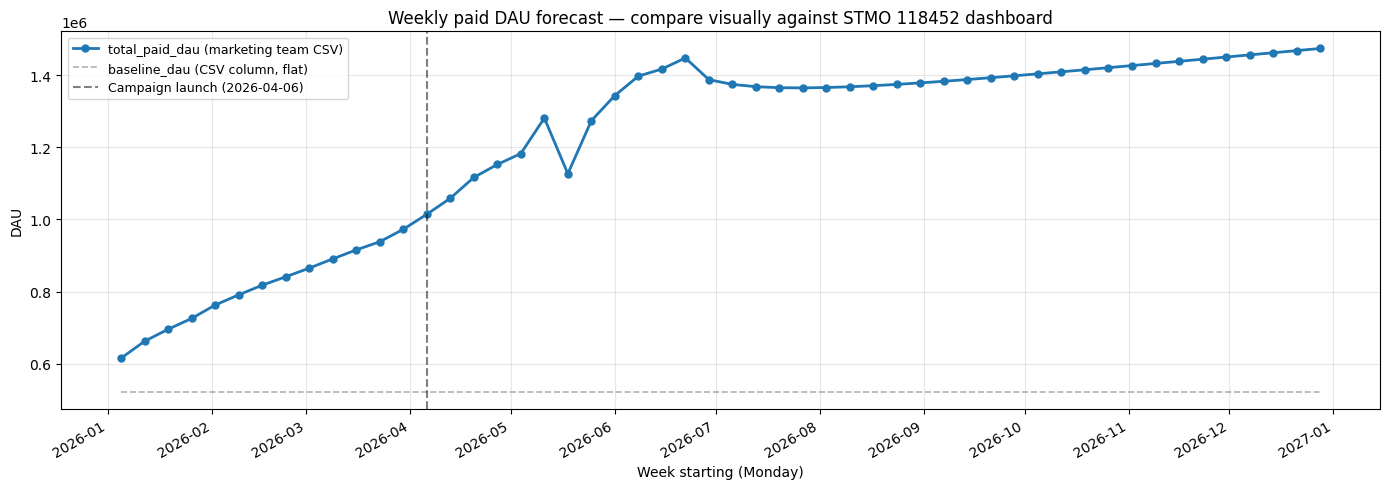

In [3]:
# [plot-raw-weekly]
# Visual sanity check: open STMO 118452 dashboard
# (https://sql.telemetry.mozilla.org/queries/118452/source) and compare the
# shape and magnitude of this CSV's `total_paid_dau` curve to the dashboard's
# `paid_dau_ex_iran_ma28` series. They are NOT the same model — STMO 118452 is
# DS team's cohort-based view, the CSV is marketing team's independent forecast
# — but they should be in the same ballpark.

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(weekly['week_starting'], weekly['total_paid_dau'],
        '-o', linewidth=2, markersize=5, color='C0',
        label='total_paid_dau (marketing team CSV)')
ax.plot(weekly['week_starting'], weekly['baseline_dau'],
        '--', linewidth=1.2, color='grey', alpha=0.6,
        label='baseline_dau (CSV column, flat)')

ax.axvline(CAMPAIGN_LAUNCH, color='black', linestyle='--', alpha=0.5,
           label=f'Campaign launch ({CAMPAIGN_LAUNCH.date()})')

ax.set_title('Weekly paid DAU forecast — compare visually against STMO 118452 dashboard')
ax.set_ylabel('DAU')
ax.set_xlabel('Week starting (Monday)')
ax.legend(fontsize=9, loc='upper left')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Shifting definitions — three live caveats

These get carried into the `.meta.json:caveats` array of the exported artifact in `02_forecast_projection.ipynb`.

**1. Three parallel "Paid DAU" definitions are in play.**
- **Marketing team's CSV** (`paid_dau_weekly_forecast.20260519.csv`) — their own model. This is our source of truth for the lift series.
- **DS team's STMO query 118452** (`mozdata.fenix.active_users` with cohort-based attribution: any client ever paid-acquired via Play Store + gclid → all future DAU rows count as Paid). NOT the source of the CSV — a parallel published view of the same underlying signal, useful for visual magnitude sanity-check.
- **`*_marketing_geo_testing_v1` tables** (under `fenix_derived` / `firefox_ios_derived`) — a third, separate attribution definition. **Flagged as WRONG by the user on 2026-05-19.** Never use them as a cross-check or fallback.

**2. Channel filter is unknown.**
STMO 118452 has `normalized_channel = 'release'` **commented out** in its `paid_clients` CTE — so all channels (release + beta + nightly) are included in the cohort. The marketing team's CSV doesn't document its filter choice. The convolution model in `.claude/worktrees/marketing-lift/marketing_lift_model/` filtered to release-only. If our magnitudes diverge meaningfully from the convolution model or from the STMO dashboard, the channel filter is a likely suspect.

**3. Ex-Iran is assumed.**
We assume the CSV uses ex-Iran (IR country + `fa`-locale excluded), matching the convolution model's baseline. If the CSV actually includes Iran, magnitudes would be inflated by Iran's contribution to the Paid cohort. The Validation A residual in `02_forecast_projection.ipynb` will surface this if it's wrong.


In [4]:
# [export-clean]
CLEAN_PARQUET.parent.mkdir(exist_ok=True)
weekly.to_parquet(CLEAN_PARQUET, index=False)

print(f'Wrote {CLEAN_PARQUET}')
print()
print('Schema:')
print(weekly.dtypes.to_string())
print()
print(f'Rows: {len(weekly)}')
print(f'Date range: {weekly["week_starting"].min().date()} → {weekly["week_starting"].max().date()}')


Wrote data/weekly_paid_dau_clean.parquet

Schema:
week_starting     datetime64[ns]
baseline_dau               int64
post_2026_dau              int64
total_paid_dau             int64

Rows: 52
Date range: 2026-01-05 → 2026-12-28
